# GD + FPL Sampling Study

We have unlimited compute and want GD on the full FPL cost — not just smoothness — combined
with population-based sampling.  Two approaches:

**Experiment 1 — BPTT GD** (`cost_gd.py`, already exists):  
Reverse-mode adjoint through `mjd_transitionFD` Jacobians. Analytic gradient of the power-mean
aggregation + per-step FD on the cost terms.  Works on all cost modes.  The position gradient for
free-joint models (g1_standup: nq ≠ nv) is taken in tangent space via `mj_integratePos` so it
lines up with the velocity-space A/B Jacobians — the code already handles this correctly despite
the `make_controller` docstring suggesting otherwise.

**Experiment 2 — SPSA GD** (implemented here):  
Zeroth-order gradient via trajectory-level cost finite differences in *control space*.  Only needs
`backend.rollout` — no Jacobians, no `mjd_transitionFD`.  Two extra rollouts per elite per GD
step.  Contact-safe: the FD straddles contact events in control space (not state space), so the
estimate is a smoothed gradient of the cost landscape.  Useful when BPTT gradients are too noisy
(g1_standup body-ground contact transitions, cube finger contacts).

Both wrappers work on any `SamplingController` in FPL mode (fpl_cost or fpl_discounted).
The BPTT wrapper is `wrap_controller_with_gd_refine` from `cost_gd.py`.
The SPSA wrapper is defined in this notebook.

**Order:**
1. Sanity-check BPTT GD on pendulum (quick, compare to known DP optimum)
2. BPTT GD on g1_standup (main experiment — does BPTT help through contact?)
3. SPSA implementation
4. SPSA vs BPTT vs baseline on g1_standup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from types import MethodType

import analytic_mppi
from analytic_mppi.eval import (
    Config, run_study, make_controller,
    g1_metrics, g1_panels, plot_study, summarize,
    pendulum_metrics, pendulum_panels,
    init_hang_down,
)
from analytic_mppi.tasks import power_mean
from analytic_mppi.controllers.experimental import FplGmmSampler
from analytic_mppi.controllers.cost_gd import wrap_controller_with_gd_refine
from analytic_mppi.controllers.sampling_base import Trajectory
from analytic_mppi.controllers.spline import interpolate

REPO = Path(analytic_mppi.__file__).resolve().parents[1]

# ---- shared run parameters ----
NUM_SAMPLES = 256   # keep manageable; increase for final runs
NUM_KNOTS   = 6
PLAN_HORIZON = 1.0
N_EPISODES  = 1     # set to 3+ for statistics; 1 is fast for initial inspection
STEPS       = 300   # timesteps per episode

## 1  Sanity check: BPTT GD on pendulum

Pendulum has smooth dynamics (no contact, nq == nv), so BPTT gradients are exact.
Compare against the DP optimum from `data/pendulum_dp_fpl_cost.npz`.
This confirms the GD wrapper is working before we move to the harder task.

In [2]:
DP_PATH = REPO / "data" / "pendulum_dp_fpl_cost.npz"
GAMMA, FPL_P = 0.99, 0.1
TWO_PI = 2.0 * np.pi
PEND_STEPS = 200

_d = np.load(DP_PATH, allow_pickle=True)
theta_grid, thetadot_grid = _d["theta_grid"], _d["thetadot_grid"]
V_star = _d["V"]
dp_return = float(_d["traj_discounted_return"])

_n_th, _n_td = V_star.shape
_dth = TWO_PI / _n_th
_td_min, _td_max = thetadot_grid[0], thetadot_grid[-1]
_dtd = (_td_max - _td_min) / (_n_td - 1)

def interpV(Vg, th, td):
    th = np.mod(th, TWO_PI); f = th / _dth
    i0 = np.floor(f).astype(int) % _n_th; i1 = (i0 + 1) % _n_th; wt = f - np.floor(f)
    tc = np.clip(td, _td_min, _td_max); g = (tc - _td_min) / _dtd
    j0 = np.clip(np.floor(g).astype(int), 0, _n_td - 2); j1 = j0 + 1; wd = g - j0
    return ((1-wt)*(1-wd)*Vg[i0,j0] + wt*(1-wd)*Vg[i1,j0]
            + (1-wt)*wd*Vg[i0,j1] + wt*wd*Vg[i1,j1])

def pend_fpl_step_reward(task, qpos_next, u):
    from analytic_mppi.tasks import power_mean
    qv = np.zeros_like(qpos_next)
    sd = np.zeros(qpos_next.shape[:-1] + (task.nsensordata,))
    return power_mean(task.running_cost_terms_f(qpos_next, qv, sd, u), FPL_P)

def run_pendulum_capture(algo, cost_mode, **kw):
    task, backend, ctrl = make_controller(
        "pendulum", algo, cost_mode=cost_mode,
        num_samples=512, num_knots=6, plan_horizon=1.0, **kw)
    init_hang_down(backend)
    state = backend.get_state()
    theta, thetadot, rewards = [state[1]], [state[2]], []
    for _ in range(PEND_STEPS):
        u = ctrl.act(state)
        state = backend.step(u)
        theta.append(state[1]); thetadot.append(state[2])
        rewards.append(float(pend_fpl_step_reward(
            task, state[backend.qpos_slice][None], u[None])[0]))
    ret = float((GAMMA ** np.arange(len(rewards)) * rewards).sum())
    return dict(theta=np.array(theta), thetadot=np.array(thetadot),
                ret=ret)

print(f"DP realized return (200 steps): {dp_return:.3f}")

DP realized return (200 steps): 32.294


In [3]:
pend_runs = {
    "fpl_gmm  (no GD)":        run_pendulum_capture(
        "fpl_gmm", "fpl_cost", sigma_max=1.0, sigma_min=0.1),
    "fpl_gmm  GD iters=3":     run_pendulum_capture(
        "fpl_gmm", "fpl_cost", sigma_max=1.0, sigma_min=0.1,
        cost_gd=dict(gd_iterations=3, gd_lr=0.05)),
    "fpl_gmm  GD iters=10":    run_pendulum_capture(
        "fpl_gmm", "fpl_cost", sigma_max=1.0, sigma_min=0.1,
        cost_gd=dict(gd_iterations=10, gd_lr=0.02)),
    "fpl_gmm  GD iters=20":    run_pendulum_capture(
        "fpl_gmm", "fpl_cost", sigma_max=1.0, sigma_min=0.1,
        cost_gd=dict(gd_iterations=20, gd_lr=0.01)),
}

print(f"{'controller':35s}  {'return':>8s}  {'gap->DP':>8s}  {'|θ-π| final':>12s}")
print("-" * 70)
print(f"{'DP optimal (ceiling)':35s}  {dp_return:8.3f}")
for name, r in pend_runs.items():
    err = abs(((r["theta"][-1] - np.pi + np.pi) % TWO_PI) - np.pi)
    print(f"{name:35s}  {r['ret']:8.3f}  {dp_return - r['ret']:8.3f}  {err:12.3f}")

controller                             return   gap->DP   |θ-π| final
----------------------------------------------------------------------
DP optimal (ceiling)                   32.294
fpl_gmm  (no GD)                       26.791     5.503         0.046
fpl_gmm  GD iters=3                    27.096     5.198         0.054
fpl_gmm  GD iters=10                   27.302     4.992         0.062
fpl_gmm  GD iters=20                   27.302     4.992         0.062


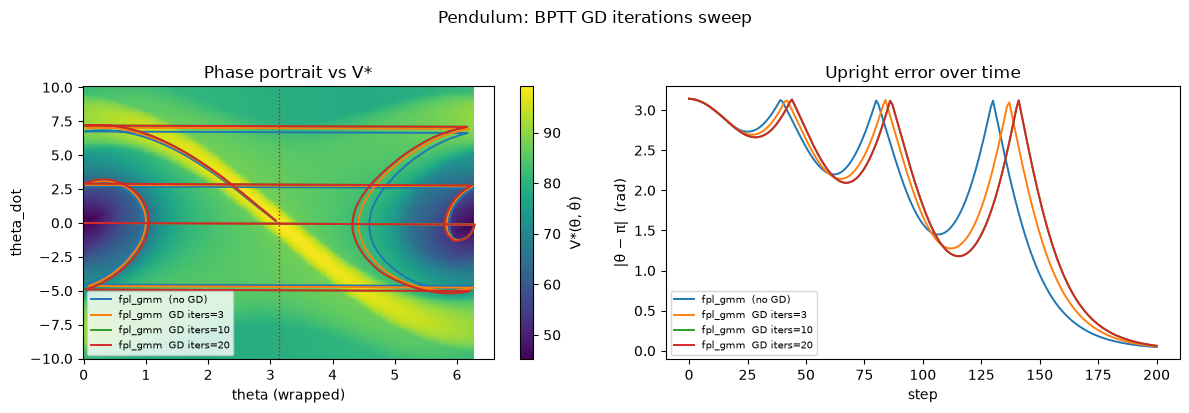

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pcm = axes[0].pcolormesh(theta_grid, thetadot_grid, V_star.T, shading="auto", cmap="viridis")
fig.colorbar(pcm, ax=axes[0], label="V*(θ, θ̇)")
for name, r in pend_runs.items():
    axes[0].plot(np.mod(r["theta"], TWO_PI), r["thetadot"], lw=1.4, label=name)
axes[0].axvline(np.pi, color="r", ls=":", lw=1)
axes[0].set(xlabel="theta (wrapped)", ylabel="theta_dot", title="Phase portrait vs V*")
axes[0].legend(fontsize=7)

t = np.arange(PEND_STEPS + 1)
for name, r in pend_runs.items():
    err = np.abs(((r["theta"] - np.pi + np.pi) % TWO_PI) - np.pi)
    axes[1].plot(t, err, lw=1.4, label=name)
axes[1].set(xlabel="step", ylabel="|θ − π|  (rad)", title="Upright error over time")
axes[1].legend(fontsize=7)
fig.suptitle("Pendulum: BPTT GD iterations sweep", y=1.02)
fig.tight_layout(); plt.show()

## 2  BPTT GD on g1_standup

G1 is a free-joint model (nq ≠ nv).  `cost_gd.py` handles this via tangent-space FD
(`mj_integratePos`) — the note in `make_controller`'s docstring that says `cost_gd`
"requires nq == nv" is stale; the underlying `gd_refine_topmu` already supports free joints.

Three objectives in FPL mode:
- `orientation_fulfillment`: torso z-axis alignment  
- `height_fulfillment`: torso height vs target  
- `nominal_fulfillment`: joint deviation from stand pose  

With p=0.1, GD automatically prioritizes whichever term is most violated
(the quasi-geometric mean's gradient is dominated by the weakest term).
This is useful here: early in the episode, orientation and height are near zero,
so GD pushes almost entirely on getting the robot upright first.

Starting pose: the "stand" keyframe (model default).
The task tests whether GD can improve the quality of sampled plans — not whether
the robot can stand up from lying down (that would require a different initial state).

In [5]:
def init_g1_stand(backend):
    """Initialize G1 from the 'stand' keyframe (default sensible starting pose)."""
    import mujoco
    kf = backend.model.keyframe("stand")
    backend.data.qpos[:] = kf.qpos
    backend.data.qvel[:] = 0.0
    mujoco.mj_forward(backend.model, backend.data)
    # Re-sync the state buffer so get_state() returns the updated pose.
    _ = backend.get_state()

# Quick check: what are the model dimensions?
from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
task_g1 = make_task("g1_standup")
backend_g1 = MujocoBackend(task_g1.model_path)
print(f"G1 model: nq={backend_g1.nq}  nv={backend_g1.nv}  nu={backend_g1.nu}")
print(f"  free-joint: {backend_g1.nq != backend_g1.nv}  (cost_gd.py uses tangent-space FD for this)")
del task_g1, backend_g1

G1 model: nq=36  nv=35  nu=29
  free-joint: True  (cost_gd.py uses tangent-space FD for this)


In [6]:
# Note: cost_gd is an instance-level wrapper; Config passes it to make_controller -> wrap_controller_with_gd_refine.
g1_configs_bptt = [
    Config("normal_mppi  (reference)",
           "mppi", "normal",
           dict(noise_level=0.3, temperature=0.1)),
    Config("fpl_gmm  (no GD)",
           "fpl_gmm", "fpl_cost",
           dict(sigma_max=1.0, sigma_min=0.1)),
    Config("fpl_gmm  BPTT iters=3  lr=0.05",
           "fpl_gmm", "fpl_cost",
           dict(sigma_max=1.0, sigma_min=0.1),
           cost_gd=dict(gd_iterations=3, gd_lr=0.05)),
    Config("fpl_gmm  BPTT iters=10 lr=0.02",
           "fpl_gmm", "fpl_cost",
           dict(sigma_max=1.0, sigma_min=0.1),
           cost_gd=dict(gd_iterations=10, gd_lr=0.02)),
]

print("Running g1_standup BPTT study (this takes a few minutes)...")
g1_study_bptt = run_study(
    "g1_standup", g1_configs_bptt,
    steps=STEPS, n_episodes=N_EPISODES,
    num_samples=NUM_SAMPLES, plan_horizon=PLAN_HORIZON, num_knots=NUM_KNOTS,
    init_fn=init_g1_stand,
)

Running g1_standup BPTT study (this takes a few minutes)...
running normal_mppi  (reference)                . done
running fpl_gmm  (no GD)                        . done
running fpl_gmm  BPTT iters=3  lr=0.05          . done
running fpl_gmm  BPTT iters=10 lr=0.02          . done


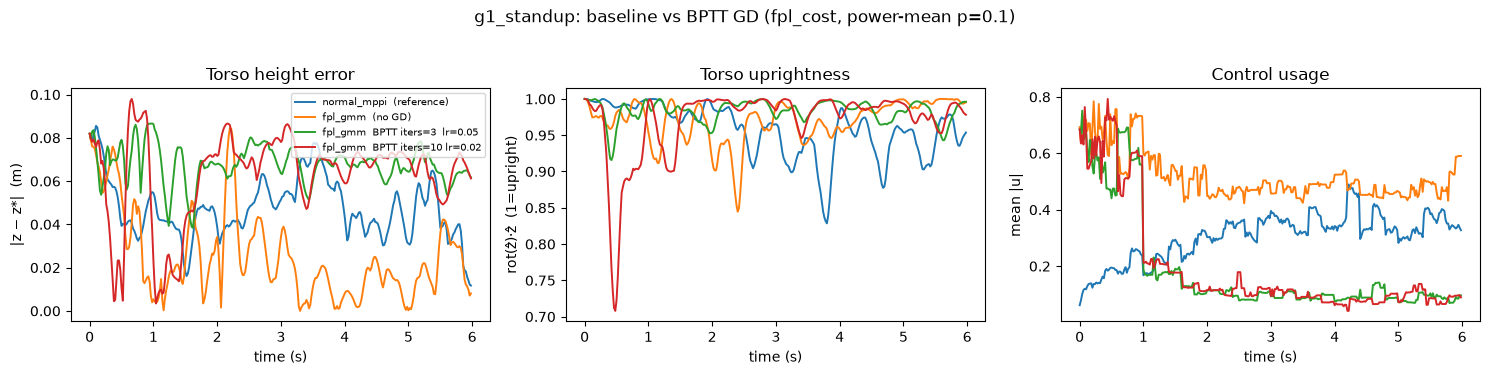


Mean metrics (lower height_err and u_mag, higher upright = better):
config                                      height_err       upright         u_mag
normal_mppi  (reference)                        0.0475        0.9578        0.3039
fpl_gmm  (no GD)                                0.0254        0.9702        0.5165
fpl_gmm  BPTT iters=3  lr=0.05                  0.0678        0.9833        0.1861
fpl_gmm  BPTT iters=10 lr=0.02                  0.0627        0.9705        0.1939


In [7]:
task_g1_plot = make_task("g1_standup")
fig = plot_study(
    g1_study_bptt,
    lambda r: g1_metrics(r, task_g1_plot),
    g1_panels(),
    dt=0.02,
    title="g1_standup: baseline vs BPTT GD (fpl_cost, power-mean p=0.1)",
)
plt.show()

print("\nMean metrics (lower height_err and u_mag, higher upright = better):")
summarize(g1_study_bptt, lambda r: g1_metrics(r, task_g1_plot),
          ["height_err", "upright", "u_mag"])

### 2a  How does BPTT gradient quality change with GD iterations?

Plot the gradient norm and cost reduction across GD iterations for a single MPC step.
If gradient norms collapse or costs plateau early, fewer iterations may suffice.
If costs oscillate or increase, the learning rate is too high or contact makes the gradient unreliable.

In [8]:
# Probe gradient quality on a single MPC step at the initial state.
# We instrument gd_refine_topmu to record per-iteration cost and gradient norms.

from analytic_mppi.controllers.cost_gd import (
    rollout_with_jacobians, cost_and_grad, bptt_grad_du
)

def probe_bptt_iters(task_name, n_iters=20, gd_lr=0.02, num_refine=4,
                     num_samples=64, plan_horizon=1.0, num_knots=6,
                     cost_mode="fpl_cost", fpl_p=0.1, fpl_gamma=0.99,
                     init_fn=None):
    """Run a single sampling step, then take n_iters GD steps on the top rollouts,
    recording the cost and gradient norm at each iteration."""
    import mujoco
    task, backend, ctrl = make_controller(
        task_name, "fpl_gmm", cost_mode=cost_mode, fpl_p=fpl_p, fpl_gamma=fpl_gamma,
        num_samples=num_samples, plan_horizon=plan_horizon, num_knots=num_knots,
        sigma_max=1.0, sigma_min=0.1)
    if init_fn:
        init_fn(backend)
    state = backend.get_state()

    # Sample and roll out (one round without GD)
    knots = ctrl.sample_knots()
    np.clip(knots, task.u_min, task.u_max, out=knots)
    controls = interpolate(knots, ctrl.tk, ctrl.t_eval, ctrl.spline_type)
    K = controls.shape[0]
    initial = np.broadcast_to(state, (K, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)

    # Score and select top rollouts
    qpos = task.qpos_of(states); qvel = task.qvel_of(states)
    traj = Trajectory(knots=knots, controls=controls, states=states,
                      sensordata=sensordata, qpos=qpos, qvel=qvel)
    traj.running_terms_f  = task.running_cost_terms_f(qpos, qvel, sensordata, controls)
    traj.terminal_terms_f = task.terminal_cost_terms_f(qpos[:,-1], qvel[:,-1], sensordata[:,-1])
    pre_scores = ctrl._score_fpl(traj)   # (K,), smaller = better

    M = min(num_refine, K)
    elite_idx = np.sort(np.argpartition(pre_scores, M-1)[:M])
    controls_e = controls[elite_idx].copy()
    initial_e  = initial[elite_idx].copy()

    u_min = np.asarray(task.u_min, dtype=np.float64)
    u_max = np.asarray(task.u_max, dtype=np.float64)
    nv, na = int(backend.model.nv), int(backend.model.na)
    ns_v = 2*nv + na

    costs_hist, gnorm_hist = [], []
    for _ in range(n_iters):
        states_e, sd_e, A_seq, B_seq, *_ = rollout_with_jacobians(backend, initial_e, controls_e)
        qpos_e, qvel_e = task.qpos_of(states_e), task.qvel_of(states_e)
        J, dJ_dq, dJ_dv, dJ_ds, dJ_du, dJ_dq_T, dJ_dv_T, dJ_ds_T = cost_and_grad(
            qpos_e, qvel_e, sd_e, controls_e, task, cost_mode, backend.dt, fpl_p, fpl_gamma)
        dJ_dq = dJ_dq.copy(); dJ_dv = dJ_dv.copy()
        dJ_dq[:,-1] += dJ_dq_T; dJ_dv[:,-1] += dJ_dv_T
        dJ_dstate = np.zeros((M, states_e.shape[1], ns_v), dtype=np.float64)
        dJ_dstate[..., :nv] = dJ_dq; dJ_dstate[..., nv:2*nv] = dJ_dv
        grad = bptt_grad_du(A_seq, B_seq, dJ_dstate, dJ_du)
        costs_hist.append(float(J.mean()))
        gnorm_hist.append(float(np.sqrt((grad**2).sum(axis=(1,2)).mean())))
        controls_e = np.clip(controls_e - gd_lr * grad, u_min, u_max)

    return np.array(costs_hist), np.array(gnorm_hist)

print("Probing BPTT gradient quality on pendulum (smooth, reference)...")
costs_pend, gnorms_pend = probe_bptt_iters("pendulum", n_iters=20, gd_lr=0.02,
                                            init_fn=init_hang_down)
print("Probing BPTT gradient quality on g1_standup (contact)...")
costs_g1, gnorms_g1 = probe_bptt_iters("g1_standup", n_iters=20, gd_lr=0.02,
                                         init_fn=init_g1_stand)

Probing BPTT gradient quality on pendulum (smooth, reference)...
Probing BPTT gradient quality on g1_standup (contact)...


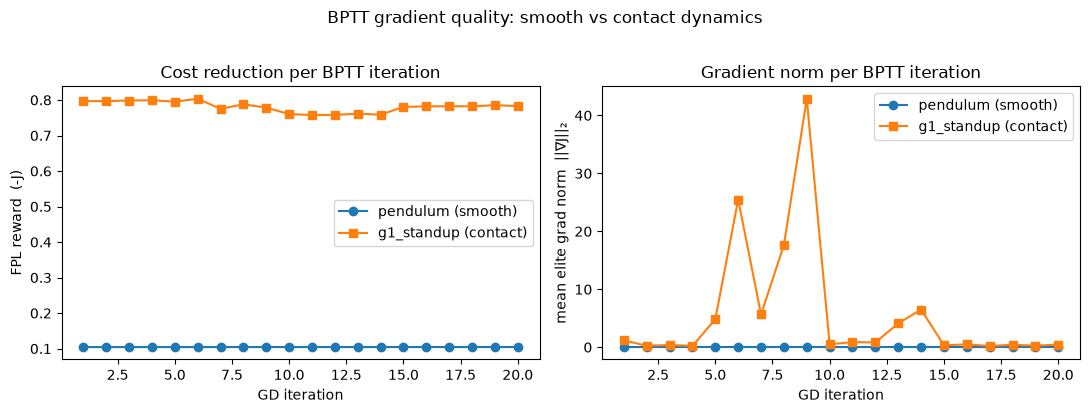

Pendulum: cost drop over 20 iters = 0.0001
G1:       cost drop over 20 iters = -0.0141


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
iters = np.arange(1, 21)
axes[0].plot(iters, -costs_pend, "o-", label="pendulum (smooth)")
axes[0].plot(iters, -costs_g1,   "s-", label="g1_standup (contact)")
axes[0].set(xlabel="GD iteration", ylabel="FPL reward  (-J)",
            title="Cost reduction per BPTT iteration")
axes[0].legend()

axes[1].plot(iters, gnorms_pend, "o-", label="pendulum (smooth)")
axes[1].plot(iters, gnorms_g1,   "s-", label="g1_standup (contact)")
axes[1].set(xlabel="GD iteration", ylabel="mean elite grad norm  ||∇J||₂",
            title="Gradient norm per BPTT iteration")
axes[1].legend()
fig.suptitle("BPTT gradient quality: smooth vs contact dynamics", y=1.02)
fig.tight_layout(); plt.show()

print(f"Pendulum: cost drop over 20 iters = {-costs_pend[-1] - (-costs_pend[0]):.4f}")
print(f"G1:       cost drop over 20 iters = {-costs_g1[-1]   - (-costs_g1[0]):.4f}")

## 3  SPSA: zeroth-order, contact-safe GD

**Key idea:** instead of backpropagating through the dynamics Jacobians, estimate the gradient
entirely from trajectory-level cost differences in *control space*.

For each elite control sequence **u** (shape H × nu), draw a random direction **Δ** and evaluate:

$$\hat{g} = \frac{J(\mathbf{u} + \varepsilon \mathbf{\Delta}) - J(\mathbf{u} - \varepsilon \mathbf{\Delta})}{2\varepsilon} \cdot \mathbf{\Delta}$$

Update: $\mathbf{u} \leftarrow \text{clip}(\mathbf{u} - \alpha \hat{g},\ u_{\min},\ u_{\max})$

This is a smoothed-gradient estimator: $\hat{g}$ is an unbiased estimate of
$\nabla_u \mathbb{E}_{\mathbf{\Delta}}[J(\mathbf{u} + \varepsilon\mathbf{\Delta})]$,
i.e., the gradient of the Gaussian-smoothed cost.  Contact discontinuities are averaged
over in the smoothing — the estimate is always well-defined.

**Cost per GD step:** 2 × M_elite extra rollouts (batched), vs 2×nv×M for BPTT FD on state.
For G1 (nv ≈ 36), SPSA is ~36× cheaper per step than the state-space FD in cost_and_grad,
plus it avoids mjd_transitionFD entirely.

In [10]:
# ---- FPL reward scorer (no FD, just cost terms + power-mean aggregation) ----

def _fpl_reward_batch(task, states, sensordata, controls, use_fpl_cost, fpl_p, fpl_gamma):
    """FPL reward for a batch of rollouts. Returns (M,) reward, larger = better.
    Mirrors SamplingController._score_fpl without the Trajectory wrapper."""
    qpos = task.qpos_of(states)           # (M, H, nq)
    qvel = task.qvel_of(states)           # (M, H, nv)
    rt_f = task.running_cost_terms_f(qpos, qvel, sensordata, controls)        # (M, H, n_run)
    tt_f = task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sensordata[:, -1])  # (M, n_term)
    M, H, n_run = rt_f.shape
    n_term = tt_f.shape[-1]
    p, gamma = fpl_p, fpl_gamma
    H1 = H + 1
    disc_full = gamma ** np.arange(H1, dtype=np.float64)
    norm_full = (1 - gamma) / (1 - gamma ** H1)
    disc_run  = gamma ** np.arange(H,  dtype=np.float64)
    norm_run  = (1 - gamma) / (1 - gamma ** H) if H > 1 else 1.0

    if use_fpl_cost:
        ps_run = power_mean(rt_f, p)                                           # (M, H)
        if n_term > 0:
            ps_term = power_mean(tt_f, p)                                      # (M,)
            ps = np.concatenate([ps_run, ps_term[:, None]], axis=1)            # (M, H+1)
            return (ps * disc_full[None, :]).sum(axis=1) * norm_full
        return (ps_run * disc_run[None, :]).sum(axis=1) * norm_run
    else:  # fpl_discounted
        chunks = []
        if n_term > 0:
            a = ((rt_f[..., :n_term] * disc_full[:H, None]).sum(axis=1)
                 + tt_f * disc_full[H]) * norm_full
            chunks.append(a)
        if n_run > n_term:
            b = (rt_f[..., n_term:] * disc_run[:, None]).sum(axis=1) * norm_run
            chunks.append(b)
        return power_mean(np.concatenate(chunks, axis=-1), p)


# ---- SPSA refinement core ----

def gd_refine_topmu_spsa(backend, task, initial, controls, pre_scores,
                          use_fpl_cost, fpl_p, fpl_gamma,
                          gd_iterations, gd_lr, num_refine, u_min, u_max,
                          spsa_eps=0.1, rng=None):
    """SPSA zeroth-order refinement of the top-num_refine rollouts.

    Each GD step: perturb each elite ±ε in a random direction, batch-roll-out 2M
    perturbed sequences, estimate the gradient from the cost difference, step.
    Contact-safe: only uses backend.rollout, no Jacobians.

    Returns refined_controls (K, H, nu), elite_idx (num_refine,).
    """
    if rng is None:
        rng = np.random.default_rng()
    K, H, nu = controls.shape
    M = min(num_refine, K)
    elite_idx = np.sort(np.argpartition(pre_scores, M - 1)[:M]) if M < K else np.arange(K)

    controls_e = controls[elite_idx].copy()           # (M, H, nu)
    initial_e  = initial[elite_idx].copy()            # (M, nstate)
    u_min = np.asarray(u_min, dtype=np.float64)
    u_max = np.asarray(u_max, dtype=np.float64)

    for _ in range(gd_iterations):
        # Random unit direction per elite (Gaussian spherical)
        delta = rng.standard_normal(controls_e.shape)  # (M, H, nu)
        norms = np.sqrt((delta ** 2).sum(axis=(1, 2), keepdims=True)).clip(1e-8)
        delta /= norms

        c_plus  = np.clip(controls_e + spsa_eps * delta, u_min, u_max)  # (M, H, nu)
        c_minus = np.clip(controls_e - spsa_eps * delta, u_min, u_max)

        # Batch the 2M rollouts together
        all_ctrl = np.concatenate([c_plus, c_minus], axis=0)             # (2M, H, nu)
        all_init = np.concatenate([initial_e, initial_e], axis=0)        # (2M, nstate)
        all_states, all_sd = backend.rollout(all_init, all_ctrl)         # (2M, H, ...)

        J_plus  = -_fpl_reward_batch(task, all_states[:M], all_sd[:M],  c_plus,
                                      use_fpl_cost, fpl_p, fpl_gamma)    # (M,)  smaller=better
        J_minus = -_fpl_reward_batch(task, all_states[M:], all_sd[M:],  c_minus,
                                      use_fpl_cost, fpl_p, fpl_gamma)

        # Gradient estimate: scalar diff per elite × direction  ->  (M, H, nu)
        grad = ((J_plus - J_minus) / (2 * spsa_eps))[:, None, None] * delta
        controls_e = np.clip(controls_e - gd_lr * grad, u_min, u_max)

    refined = controls.copy()
    refined[elite_idx] = controls_e
    return refined, elite_idx


# ---- Controller wrapper ----

def wrap_controller_with_spsa_refine(ctrl, gd_iterations, gd_lr, num_refine=None,
                                      spsa_eps=0.1, seed=42):
    """Add SPSA zeroth-order GD refinement to a controller instance.

    Drop-in alternative to wrap_controller_with_gd_refine for contact-heavy tasks.
    Requires FPL cost mode (fpl_cost or fpl_discounted).
    """
    if not (ctrl.use_fpl_cost or ctrl.use_fpl_discounted):
        raise ValueError("SPSA wrapper requires FPL mode (fpl_cost or fpl_discounted).")

    if num_refine is None:
        num_refine_eff = (ctrl.num_elites if hasattr(ctrl, "num_elites") and ctrl.num_elites is not None
                          else min(8, ctrl.num_samples))
    else:
        num_refine_eff = int(num_refine)
    num_refine_eff = max(1, min(num_refine_eff, ctrl.num_samples))

    _rng = [np.random.default_rng(seed)]

    def wrapped_rollout_and_score(self, state):
        K = self.num_samples
        knots    = self.sample_knots()
        np.clip(knots, self.task.u_min, self.task.u_max, out=knots)
        controls = interpolate(knots, self.tk, self.t_eval, self.spline_type)
        initial  = np.broadcast_to(state, (K, self.backend.nstate)).copy()
        states, sensordata = self.backend.rollout(initial, controls)

        if gd_iterations > 0:
            # Score with -reward so "smaller = better" matches argpartition expectation.
            pre_scores = -_fpl_reward_batch(
                self.task, states, sensordata, controls,
                self.use_fpl_cost, self.fpl_p, self.fpl_gamma)
            controls, elite_idx = gd_refine_topmu_spsa(
                self.backend, self.task, initial, controls, pre_scores,
                self.use_fpl_cost, self.fpl_p, self.fpl_gamma,
                gd_iterations, gd_lr, num_refine_eff,
                self.task.u_min, self.task.u_max,
                spsa_eps=spsa_eps,
                rng=np.random.default_rng(_rng[0].integers(2**31)),
            )
            # Update knots for the refined elites (identity map when num_knots == H).
            knots = knots.copy()
            if self.num_knots == self.H:
                knots[elite_idx] = controls[elite_idx]
            # Re-roll refined controls to get updated states.
            states, sensordata = self.backend.rollout(initial, controls)

        qpos = self.task.qpos_of(states)
        qvel = self.task.qvel_of(states)
        traj = Trajectory(knots=knots, controls=controls, states=states,
                          sensordata=sensordata, qpos=qpos, qvel=qvel)
        traj.running_terms_f  = self.task.running_cost_terms_f(qpos, qvel, sensordata, controls)
        traj.terminal_terms_f = self.task.terminal_cost_terms_f(
            qpos[:, -1], qvel[:, -1], sensordata[:, -1])
        traj.scores = self._score_fpl(traj)
        return traj

    ctrl._rollout_and_score = MethodType(wrapped_rollout_and_score, ctrl)
    ctrl._spsa_wrapped = True
    ctrl._spsa_num_refine = num_refine_eff
    ctrl._spsa_iterations = gd_iterations
    return ctrl

print("SPSA implementation ready.")

SPSA implementation ready.


### 3a  SPSA gradient quality probe

Same probe as Section 2a: track cost reduction and gradient norm over iterations for both
pendulum and g1_standup.  Compare SPSA to BPTT to check whether the contact smoothing helps.

In [11]:
def probe_spsa_iters(task_name, n_iters=20, gd_lr=0.05, num_refine=4,
                     spsa_eps=0.1, num_samples=64, plan_horizon=1.0, num_knots=6,
                     cost_mode="fpl_cost", fpl_p=0.1, fpl_gamma=0.99,
                     init_fn=None):
    """Run a single sampling step, then take n_iters SPSA steps on the top rollouts."""
    task, backend, ctrl = make_controller(
        task_name, "fpl_gmm", cost_mode=cost_mode, fpl_p=fpl_p, fpl_gamma=fpl_gamma,
        num_samples=num_samples, plan_horizon=plan_horizon, num_knots=num_knots,
        sigma_max=1.0, sigma_min=0.1)
    if init_fn:
        init_fn(backend)
    state = backend.get_state()

    knots = ctrl.sample_knots()
    np.clip(knots, task.u_min, task.u_max, out=knots)
    controls = interpolate(knots, ctrl.tk, ctrl.t_eval, ctrl.spline_type)
    K = controls.shape[0]
    initial = np.broadcast_to(state, (K, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)

    # Select top rollouts
    pre_scores = -_fpl_reward_batch(task, states, sensordata, controls,
                                     ctrl.use_fpl_cost, fpl_p, fpl_gamma)
    M = min(num_refine, K)
    elite_idx = np.sort(np.argpartition(pre_scores, M-1)[:M])
    controls_e = controls[elite_idx].copy()
    initial_e  = initial[elite_idx].copy()
    u_min = np.asarray(task.u_min, dtype=np.float64)
    u_max = np.asarray(task.u_max, dtype=np.float64)
    rng = np.random.default_rng(0)

    costs_hist, gnorm_hist = [], []
    for _ in range(n_iters):
        delta = rng.standard_normal(controls_e.shape)
        norms = np.sqrt((delta**2).sum(axis=(1,2), keepdims=True)).clip(1e-8)
        delta /= norms
        c_plus  = np.clip(controls_e + spsa_eps * delta, u_min, u_max)
        c_minus = np.clip(controls_e - spsa_eps * delta, u_min, u_max)
        all_ctrl = np.concatenate([c_plus, c_minus], axis=0)
        all_init = np.concatenate([initial_e, initial_e], axis=0)
        all_states, all_sd = backend.rollout(all_init, all_ctrl)
        J_plus  = -_fpl_reward_batch(task, all_states[:M], all_sd[:M],  c_plus,
                                      ctrl.use_fpl_cost, fpl_p, fpl_gamma)
        J_minus = -_fpl_reward_batch(task, all_states[M:], all_sd[M:], c_minus,
                                      ctrl.use_fpl_cost, fpl_p, fpl_gamma)
        grad = ((J_plus - J_minus) / (2*spsa_eps))[:, None, None] * delta
        costs_hist.append(float(J_plus.mean()))  # cost before the step
        gnorm_hist.append(float(np.sqrt((grad**2).sum(axis=(1,2)).mean())))
        controls_e = np.clip(controls_e - gd_lr * grad, u_min, u_max)

    return np.array(costs_hist), np.array(gnorm_hist)


print("Probing SPSA gradient quality on pendulum...")
costs_spsa_pend, gnorms_spsa_pend = probe_spsa_iters(
    "pendulum", n_iters=20, init_fn=init_hang_down)
print("Probing SPSA gradient quality on g1_standup...")
costs_spsa_g1, gnorms_spsa_g1 = probe_spsa_iters(
    "g1_standup", n_iters=20, init_fn=init_g1_stand)

Probing SPSA gradient quality on pendulum...
Probing SPSA gradient quality on g1_standup...


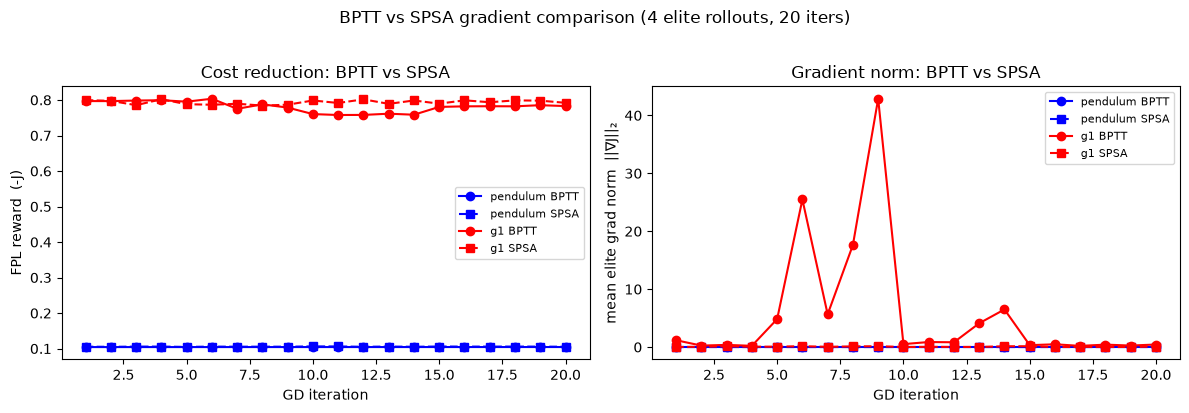

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
iters = np.arange(1, 21)

# Cost reduction: BPTT vs SPSA
axes[0].plot(iters, -costs_pend,      "b-o",  label="pendulum BPTT")
axes[0].plot(iters, -costs_spsa_pend, "b--s", label="pendulum SPSA")
axes[0].plot(iters, -costs_g1,        "r-o",  label="g1 BPTT")
axes[0].plot(iters, -costs_spsa_g1,   "r--s", label="g1 SPSA")
axes[0].set(xlabel="GD iteration", ylabel="FPL reward  (-J)",
            title="Cost reduction: BPTT vs SPSA")
axes[0].legend(fontsize=8)

axes[1].plot(iters, gnorms_pend,      "b-o",  label="pendulum BPTT")
axes[1].plot(iters, gnorms_spsa_pend, "b--s", label="pendulum SPSA")
axes[1].plot(iters, gnorms_g1,        "r-o",  label="g1 BPTT")
axes[1].plot(iters, gnorms_spsa_g1,   "r--s", label="g1 SPSA")
axes[1].set(xlabel="GD iteration", ylabel="mean elite grad norm  ||∇J||₂",
            title="Gradient norm: BPTT vs SPSA")
axes[1].legend(fontsize=8)

fig.suptitle("BPTT vs SPSA gradient comparison (4 elite rollouts, 20 iters)", y=1.02)
fig.tight_layout(); plt.show()

## 4  Full closed-loop comparison on g1_standup

Run all variants head-to-head: baseline, BPTT GD, SPSA GD.
Same num_samples, same plan_horizon, same seed.
The per-step GD budget is the key variable: both GD variants spend extra compute
per MPC step (BPTT spends it on Jacobians; SPSA spends it on extra rollouts).

In [13]:
# Build configs for run_study. For SPSA we can't use run_study directly (it's not
# a Config kwarg), so we run SPSA episodes manually and merge into the study dict.

g1_configs_full = [
    Config("normal_mppi  (reference)",
           "mppi", "normal",
           dict(noise_level=0.3, temperature=0.1)),
    Config("fpl_gmm  (no GD)",
           "fpl_gmm", "fpl_cost",
           dict(sigma_max=1.0, sigma_min=0.1)),
    Config("fpl_gmm  BPTT iters=10 lr=0.02",
           "fpl_gmm", "fpl_cost",
           dict(sigma_max=1.0, sigma_min=0.1),
           cost_gd=dict(gd_iterations=10, gd_lr=0.02)),
]

print("Running g1_standup comparison (baseline + BPTT)...")
g1_study_full = run_study(
    "g1_standup", g1_configs_full,
    steps=STEPS, n_episodes=N_EPISODES,
    num_samples=NUM_SAMPLES, plan_horizon=PLAN_HORIZON, num_knots=NUM_KNOTS,
    init_fn=init_g1_stand,
)

Running g1_standup comparison (baseline + BPTT)...
running normal_mppi  (reference)                . done
running fpl_gmm  (no GD)                        . done
running fpl_gmm  BPTT iters=10 lr=0.02          . done


In [14]:
from analytic_mppi.eval import run_episode

def run_episode_with_wrapper(task_name, wrapper_fn, steps, init_fn, seed=0,
                              cost_mode="fpl_cost", **build_kw):
    """run_episode equivalent for controllers that need a post-build wrapper."""
    task, backend, ctrl = make_controller(
        task_name, "fpl_gmm", cost_mode=cost_mode, seed=seed, **build_kw)
    wrapper_fn(ctrl)
    if init_fn:
        init_fn(backend)
    state = backend.get_state()
    states_h, ctrls_h, sd_h = [state.copy()], [], []
    for _ in range(steps):
        u = ctrl.act(state)
        state = backend.step(u)
        states_h.append(state.copy())
        ctrls_h.append(u.copy())
        sd_h.append(np.asarray(backend.data.sensordata).copy())
    return dict(states=np.array(states_h), ctrls=np.array(ctrls_h), sd=np.array(sd_h))


# SPSA wrapper factory
def spsa_wrapper(ctrl):
    wrap_controller_with_spsa_refine(ctrl, gd_iterations=10, gd_lr=0.05,
                                      spsa_eps=0.1, seed=42)

print("Running g1_standup with SPSA GD...")
spsa_episodes = [
    run_episode_with_wrapper(
        "g1_standup", spsa_wrapper, steps=STEPS, init_fn=init_g1_stand,
        seed=ep,
        num_samples=NUM_SAMPLES, plan_horizon=PLAN_HORIZON, num_knots=NUM_KNOTS,
        sigma_max=1.0, sigma_min=0.1,
    )
    for ep in range(N_EPISODES)
]
g1_study_full["fpl_gmm  SPSA iters=10 eps=0.1"] = dict(
    states=np.stack([e["states"] for e in spsa_episodes]),
    ctrls =np.stack([e["ctrls"]  for e in spsa_episodes]),
    sd    =np.stack([e["sd"]     for e in spsa_episodes]),
)
print("done.")

Running g1_standup with SPSA GD...
done.


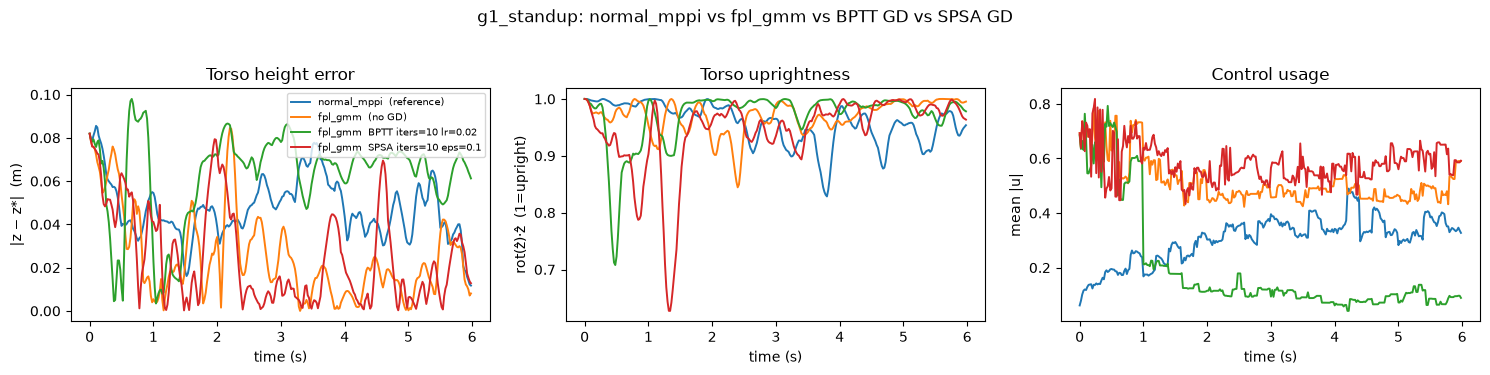


Summary (mean over episode and time):
config                                      height_err       upright         u_mag
normal_mppi  (reference)                        0.0475        0.9578        0.3039
fpl_gmm  (no GD)                                0.0254        0.9702        0.5165
fpl_gmm  BPTT iters=10 lr=0.02                  0.0627        0.9705        0.1939
fpl_gmm  SPSA iters=10 eps=0.1                  0.0253        0.9446        0.5814


In [15]:
task_g1_plot2 = make_task("g1_standup")
fig = plot_study(
    g1_study_full,
    lambda r: g1_metrics(r, task_g1_plot2),
    g1_panels(),
    dt=0.02,
    title="g1_standup: normal_mppi vs fpl_gmm vs BPTT GD vs SPSA GD",
)
plt.show()

print("\nSummary (mean over episode and time):")
summarize(g1_study_full, lambda r: g1_metrics(r, task_g1_plot2),
          ["height_err", "upright", "u_mag"])

## 5  Sensitivity: SPSA hyperparameters

Sweep the two key SPSA knobs: `spsa_eps` (perturbation size) and `gd_lr`.
Large ε gives a smoother but noisier gradient estimate; small ε is more local but less
smooth.  The optimal ε for a contact task is typically larger than for smooth dynamics.

In [16]:
# Sweep spsa_eps x gd_lr on g1_standup, measuring mean height_err over the episode.
# Keep GD iterations fixed at 5 to stay fast.

eps_grid  = [0.05, 0.1, 0.2]
lr_grid   = [0.02, 0.05, 0.1]
GD_ITERS  = 5

sweep_results = {}   # (eps, lr) -> mean_height_err
for eps in eps_grid:
    for lr in lr_grid:
        label = f"eps={eps} lr={lr}"
        print(f"  {label}", end="", flush=True)
        def _wrapper(ctrl, _eps=eps, _lr=lr):
            wrap_controller_with_spsa_refine(ctrl, gd_iterations=GD_ITERS, gd_lr=_lr,
                                              spsa_eps=_eps, seed=0)
        ep = run_episode_with_wrapper(
            "g1_standup", _wrapper, steps=STEPS, init_fn=init_g1_stand, seed=0,
            num_samples=NUM_SAMPLES, plan_horizon=PLAN_HORIZON, num_knots=NUM_KNOTS,
            sigma_max=1.0, sigma_min=0.1,
        )
        m = g1_metrics({k: v[None] for k, v in ep.items()}, make_task("g1_standup"))
        sweep_results[(eps, lr)] = float(m["height_err"].mean())
        print(f"  height_err={sweep_results[(eps, lr)]:.4f}")

print("\nSPSA sweep (mean height_err, lower=better):")
print(f"{'':12s}" + "".join(f"  lr={lr:.2f}" for lr in lr_grid))
for eps in eps_grid:
    row = "".join(f"  {sweep_results[(eps, lr)]:.4f}" for lr in lr_grid)
    print(f"eps={eps:.2f}   {row}")

  eps=0.05 lr=0.02  height_err=0.1394
  eps=0.05 lr=0.05  height_err=0.1170
  eps=0.05 lr=0.1  height_err=0.1135
  eps=0.1 lr=0.02  height_err=0.0380
  eps=0.1 lr=0.05  height_err=0.0759
  eps=0.1 lr=0.1  height_err=0.0536
  eps=0.2 lr=0.02  height_err=0.1354
  eps=0.2 lr=0.05  height_err=0.0287
  eps=0.2 lr=0.1  height_err=0.1961

SPSA sweep (mean height_err, lower=better):
              lr=0.02  lr=0.05  lr=0.10
eps=0.05     0.1394  0.1170  0.1135
eps=0.10     0.0380  0.0759  0.0536
eps=0.20     0.1354  0.0287  0.1961


## 6  Summary and findings

Fill this in after running the notebook.  Key questions to answer:

1. **Does BPTT GD help on g1_standup?** Compare Section 2 costs and Section 2a gradient quality.
   - If gradient norm stays large and cost drops monotonically → BPTT is giving useful signal.
   - If cost oscillates or gradient norm spikes → contact makes BPTT unreliable here.

2. **Is SPSA smoother than BPTT on g1_standup?** Compare the gradient probes in Section 3a.
   - SPSA should show steadier cost reduction if BPTT is being confused by contact kinks.

3. **Which wins end-to-end?** Compare the closed-loop metrics in Section 4.
   - If BPTT and SPSA both help similarly → the gradient itself is fine; compute budget is the
     constraint and SPSA is preferred (cheaper per step, contact-safe).
   - If only BPTT helps → the state-space gradient is genuinely informative and worth the cost.
   - If neither helps → the reward-faithfulness problem (Rung D from fpl_based_sampling.ipynb)
     is the real bottleneck, not the sampler quality.

4. **Best SPSA hyperparameters?** See Section 5 sweep.

**Recommended next step if GD doesn't help:** revisit power-mean exponent p (currently 0.1).
Increasing p to 0.3–0.5 gives more reward spread → argmax is more discriminating → BOTH
the GMM selection AND the GD target signal improve.  The risk is losing the FPL
"balance all objectives" property, but it's worth the trade on tasks where one objective
is already well-satisfied.